# Snapshot visualisation

Plots throughput, latency and decentralisation over time from the snapshots saved by a simulation run.

List one or more snapshot files in `names` to overlay them (e.g. runs saved with `--name pbft` and `--name tendermint`).

In [ ]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

SNAPSHOTS = Path("../Outputs/Snapshots")

# add more files here to compare runs
names = ['snapshot.json']

results = [SNAPSHOTS / name for name in names]

In [12]:
def load_metric(path, metric):
    """Returns (snapshot times, value averaged over nodes) for one metric of a snapshot file."""
    with open(path) as f:
        snapshots = json.load(f)

    times, values = [], []
    for snapshot in snapshots.values():
        per_node = [v["AVG"] if isinstance(v, dict) else v for v in snapshot["metrics"][metric].values()]
        # -1 marks intervals where no blocks were produced
        per_node = [np.nan if v == -1 else v for v in per_node]

        times.append(snapshot["time"])
        values.append(np.nanmean(per_node) if not all(np.isnan(per_node)) else np.nan)

    return times, values

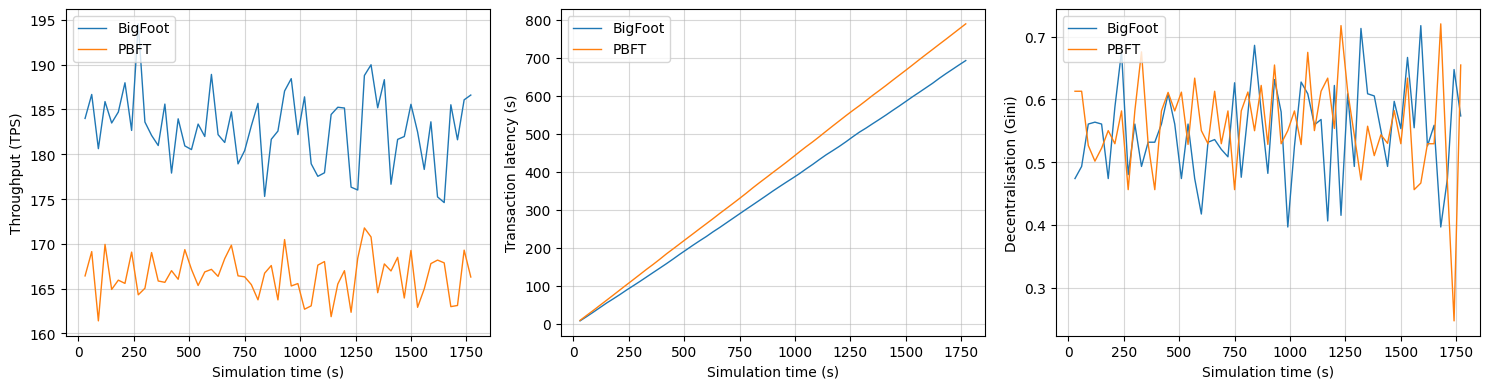

In [13]:
PLOTS = [
    ("throughput", "Throughput (TPS)"),
    ("latency", "Transaction latency (s)"),
    ("decentralisation", "Decentralisation (Gini)"),
]

fig, axes = plt.subplots(1, len(PLOTS), figsize=(15, 4))

for ax, (metric, ylabel) in zip(axes, PLOTS):
    for path in results:
        times, values = load_metric(path, metric)
        ax.plot(times, values, "-", linewidth=1, label=Path(path).stem)

    ax.set_xlabel("Simulation time (s)")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.5)
    ax.legend(loc="upper left")

plt.tight_layout()